In [ ]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found e

In [ ]:
import sionna
import numpy as np
import matplotlib.pyplot as plt

print("sionna imported successfully")
print("numpy version:", np.__version__)

sionna imported successfully
numpy version: 2.4.6


# Day 4 — Dataset Generation for Neural Channel Estimation

Today I will focus on generating input-output data for training a neural network channel estimator.

The neural network will learn from pairs of:

`noisy received pilots → true wireless channel`

This dataset will later be used to train a model that estimates the channel directly from noisy pilot observations.

In [ ]:
num_samples = 5000
num_pilots = 64
snr_db = 10

print("number of samples:", num_samples)
print("number of pilots:", num_pilots)
print("snr in db:", snr_db)

number of samples: 5000
number of pilots: 64
snr in db: 10


In [ ]:
pilot_symbols = np.ones((num_samples, num_pilots), dtype=np.complex64)

print("pilot symbols shape:", pilot_symbols.shape)
print("first sample, first 5 pilots:", pilot_symbols[0, :5])

pilot symbols shape: (5000, 64)
first sample, first 5 pilots: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]


In [ ]:
np.random.seed(42)

true_channels = (
    np.random.normal(size=(num_samples, num_pilots))
    + 1j * np.random.normal(size=(num_samples, num_pilots))
) / np.sqrt(2)

print("true channels shape:", true_channels.shape)
print("first sample, first 5 channel values:", true_channels[0, :5])

true channels shape: (5000, 64)
first sample, first 5 channel values: [ 0.35122995+0.82038791j -0.09776762+0.03173489j  0.45798496-0.33178009j
  1.07694474-0.60624029j -0.16557144-1.05354181j]


In [ ]:
received_clean = true_channels * pilot_symbols

print("received clean shape:", received_clean.shape)
print("first sample, first 5 clean received values:", received_clean[0, :5])

received clean shape: (5000, 64)
first sample, first 5 clean received values: [ 0.35122995+0.82038791j -0.09776762+0.03173489j  0.45798496-0.33178009j
  1.07694474-0.60624029j -0.16557144-1.05354181j]


In [ ]:
snr_linear = 10 ** (snr_db / 10)
noise_power = 1 / snr_linear

noise = np.sqrt(noise_power / 2) * (
    np.random.normal(size=(num_samples, num_pilots))
    + 1j * np.random.normal(size=(num_samples, num_pilots))
)

received_noisy = received_clean + noise

print("noise power:", noise_power)
print("received noisy shape:", received_noisy.shape)
print("first sample, first 5 noisy received values:", received_noisy[0, :5])

noise power: 0.1
received noisy shape: (5000, 64)
first sample, first 5 noisy received values: [ 0.40707861+0.84955273j  0.04241539-0.23890538j  0.7825859 -0.48009674j
  0.95869268-0.72743916j -0.37875071-1.34125335j]


In [8]:
x_input = np.stack(
    [received_noisy.real, received_noisy.imag],
    axis=-1
)

y_target = np.stack(
    [true_channels.real, true_channels.imag],
    axis=-1
)

print("x input shape:", x_input.shape)
print("y target shape:", y_target.shape)

x input shape: (5000, 64, 2)
y target shape: (5000, 64, 2)


In [9]:
train_ratio = 0.7
val_ratio = 0.15

num_train = int(train_ratio * num_samples)
num_val = int(val_ratio * num_samples)

x_train = x_input[:num_train]
y_train = y_target[:num_train]

x_val = x_input[num_train:num_train + num_val]
y_val = y_target[num_train:num_train + num_val]

x_test = x_input[num_train + num_val:]
y_test = y_target[num_train + num_val:]

print("training input shape:", x_train.shape)
print("validation input shape:", x_val.shape)
print("test input shape:", x_test.shape)

training input shape: (3500, 64, 2)
validation input shape: (750, 64, 2)
test input shape: (750, 64, 2)


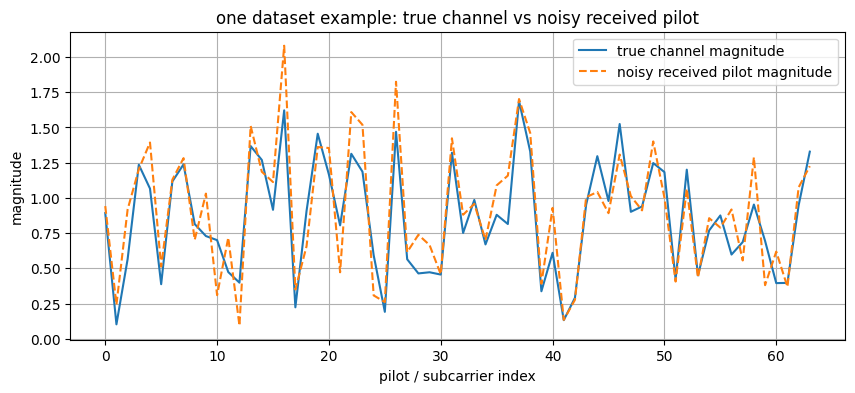

In [10]:
sample_index = 0

plt.figure(figsize=(10,4))
plt.plot(np.abs(true_channels[sample_index]), label="true channel magnitude")
plt.plot(np.abs(received_noisy[sample_index]), label="noisy received pilot magnitude", linestyle="--")
plt.title("one dataset example: true channel vs noisy received pilot")
plt.xlabel("pilot / subcarrier index")
plt.ylabel("magnitude")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
np.savez(
    "channel_estimation_dataset.npz",
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    x_test=x_test,
    y_test=y_test
)

print("dataset saved successfully")

dataset saved successfully


## Dataset Generation Summary

This notebook generated input-output pairs for neural network-based channel estimation.

Each input contains noisy received pilot observations, represented using real and imaginary parts.

Each target contains the true wireless channel, also represented using real and imaginary parts.

The final dataset shape is:

`(num_samples, num_pilots, 2)`

where:
- `num_samples` is the number of simulated wireless examples
- `num_pilots` is the number of pilot/subcarrier positions
- `2` represents real and imaginary components

This dataset will be used to train the neural channel estimator in the next stage of the project.
